## 3번 세그대중성 & 팬덤 상위권: 앵커 / 얼굴마담 / 간판 / 슈퍼노바 (Supernova, 초신성)
가장 밝게 빛나며 시스템 전체에 영향력을 미치는 중심적 존재입니다.

3번 세그먼트는 개인, 그룹, 기업/크루 여부와 관계없이  
플랫폼 내 대중성, 방송 화력, 팬덤 결집력과 외부 확장성을 함께 가진 스트리머를 찾기 위한 세그먼트이다.

기업/크루/그룹/개인 여부는 완전한 공식 데이터가 아니므로,  
전체 순위를 먼저 확인한 뒤 팬카페 기준 구분과 수동 기업 리스트를 활용해 보조적으로 나누어 비교했다.

### 라이브러리

In [608]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import math
from sklearn.preprocessing import MinMaxScaler

In [609]:
df = pd.read_csv("../data/final_softcone.csv")

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
df

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,False
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,True
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,True
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,True
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11152,sophiaten,SOOP,sophiaten,2026.03.20 ~ 2026.03.20,5,1,0,0,2,0,0,0,361.5,-100.0,0,3900,0,NaN
11153,한유0612,CHZZK,e982cd3a6093de657fa34db1bc42e98a,2026.03.30 ~ 2026.03.30,22,0,0,0,0,0,0,0,-100.0,-100.0,0,0,0,NaN
11154,dj12jdhs,SOOP,dj12jdhs,2026.03.08 ~ 2026.03.08,0,0,4,2,3,3,0,0,0.0,0.0,0,0,0,NaN
11155,afueo039,SOOP,afueo039,2025.01.21 ~ 2026.03.10,2,18,2,2,2,2,0,0,-100.0,-100.0,0,0,0,NaN


In [610]:
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,False
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,True
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,True
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,True
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,True


In [611]:
df.columns

Index(['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅',
       '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수',
       '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자', '팬카페_그룹여부'],
      dtype='str')

---
### 소속구분 기준

`팬카페_그룹여부` 컬럼은 다음과 같이 해석했다.

| 값 | 해석 |
|---|---|
| True | 그룹 팬카페로 판단된 대상 |
| False | 개인 팬카페로 판단된 대상 |
| NaN | 팬카페 정보 없음 또는 확인 불가 |

기업 여부는 별도 공식 컬럼이 없기 때문에 수동 리스트 기준으로 참고용 분류만 진행했다.  
따라서 본 분석에서는 전체 순위를 가장 우선으로 보고, 소속구분별 결과는 보조적으로 확인한다.

---
### 기업소속 확인

In [612]:
# 기업/소속/아이돌/크루로 볼 대상 리스트
# 팀 기준에 맞게 계속 추가/수정하면 됨
company_or_group_names = [
    # 예시
    "아이네", "징버거", "릴파", "주르르", "고세구", "비챤","데스해머쵸로", "시리안 레인", "융터르", "곽춘식","아마데우스최", "미미짱짱세용", "빅토리", "수셈이","198번",
    "주닝요1", "돝돝", "제갈 통", "방랑검객강풍", "야구자", "신루", "팝콘4", "길앞잡이광수", "까마귀", "우마이",
    "아야츠노 유니", "사키하네 후야", "시라유키 히나", "네네코 마시로", "아카네 리제", "아라하시 타비","텐코 시부키", "아오쿠모 린", "하나코 나나", "유즈하 리코",
    "탬탬버린", "제갈금자", "강지", "유소나"
]

In [613]:
seg3_df = df.copy()

# 팬카페_그룹여부 정리
def parse_group_value(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().upper()
    
    if x == "TRUE":
        return True
    elif x == "FALSE":
        return False
    else:
        return np.nan

seg3_df["팬카페_그룹여부_정리"] = seg3_df["팬카페_그룹여부"].apply(parse_group_value)

# 기본값: 팬카페없음
seg3_df["소속구분"] = "팬카페없음"

seg3_df.loc[
    seg3_df["팬카페_그룹여부_정리"] == False,
    "소속구분"
] = "개인팬카페"

seg3_df.loc[
    seg3_df["팬카페_그룹여부_정리"] == True,
    "소속구분"
] = "그룹팬카페"

# 기업/크루 리스트는 참고용
seg3_df.loc[
    seg3_df["스트리머명"].isin(company_or_group_names),
    "소속구분"
] = "기업(수동)"

seg3_df["소속구분"].value_counts(dropna=False)

소속구분
팬카페없음     7204
개인팬카페     3472
그룹팬카페      442
기업(수동)      39
Name: count, dtype: int64

In [614]:
# 수동 리스트 개수 확인
print("수동 리스트 개수:", len(company_or_group_names))

# 실제 데이터에 매칭된 이름 확인
matched_names = seg3_df.loc[
    seg3_df["스트리머명"].isin(company_or_group_names),
    "스트리머명"
].unique()

print("매칭된 이름 개수:", len(matched_names))

# 리스트에는 있는데 데이터에는 없는 이름
unmatched_names = set(company_or_group_names) - set(matched_names)

print("매칭 안 된 이름:")
print(unmatched_names)

수동 리스트 개수: 39
매칭된 이름 개수: 39
매칭 안 된 이름:
set()


---
### 세그먼트 점수 산정 방식

3번 세그먼트 점수는 “간판형 스트리머”를 찾기 위해  
다음 세 가지 축으로 구성했다.

1. **대중성**
   - 최고 팔로워
   - 최고 시청자
   - 유튜브 유입지수

2. **방송 화력**
   - 도네이션
   - 6분 최고채팅
   - 평균 시청자 최댓값

3. **팬덤 결집 및 누적 규모**
   - 팬덤지수
   - 뷰어십

값의 범위가 큰 지표는 `log1p` 변환을 적용해 극단값의 영향을 완화했고,  
이후 모든 지표를 0~100점으로 정규화한 뒤 가중합하여 최종 점수를 계산했다.

## 최종 계산식

3번 세그먼트 점수는 다음과 같이 계산했다.

### 1. 대중성 점수

대중성 점수는 플랫폼 내 팔로워 규모와 최고 시청자 규모를 중심으로,  
외부 유튜브 채널에서 방송 플랫폼으로 유입될 가능성을 함께 반영했다.

**대중성 점수 = 최고팔로워 50% + 최고시청자 30% + 유튜브유입지수 20%**

---

### 2. 방송화력 점수

방송화력 점수는 실제 방송 중 발생하는 후원, 채팅, 평균 시청자 반응을 중심으로 계산했다.  
따라서 방송 내 실질적인 반응과 수익화 가능성을 확인하는 지표로 활용했다.

**방송화력 점수 = 도네이션 40% + 채팅화력 30% + 평균시청자 30%**

---

### 3. 팬덤체급 점수

팬덤체급 점수는 방송 소비 규모를 나타내는 뷰어십을 중심으로,  
팬덤의 응집도를 나타내는 팬덤지수와 외부 플랫폼에서 확보한 팬덤 규모를 나타내는 유튜브구독자를 함께 반영했다.

**팬덤체급 점수 = 뷰어십 50% + 팬덤지수 30% + 유튜브구독자 20%**

---

### 4. 최종 세그먼트 점수

최종 세그먼트 점수는 대중성, 방송화력, 팬덤체급 점수를 가중합하여 계산했다.

**최종 세그먼트 점수 = 대중성 40% + 방송화력 45% + 팬덤체급 15%**

---

### 지표 반영 기준

유튜브유입지수, 팬덤지수, 유튜브구독자는 외부 지표 기반으로 결측 또는 미수집 대상이 존재할 수 있다.  
따라서 해당 지표들이 최종 점수에 과도하게 영향을 주지 않도록 보조 비중으로 반영했다.

최종 점수는 방송 내부에서 직접 관측되는 성과와 플랫폼 내 체급을 중심으로 두고,  
유튜브와 팬카페 기반 외부 지표는 확장 가능성과 외부 팬덤 규모를 보완하는 용도로 사용했다.

In [615]:
score_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "팬덤지수",
    "뷰어십",
    "유튜브_구독자"
]


for col in score_cols:
    seg3_df[col] = pd.to_numeric(seg3_df[col], errors="coerce").fillna(0)

# 값 차이가 큰 지표는 로그 변환
log_cols = [
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "뷰어십",
    "유튜브_구독자"
]

for col in log_cols:
    seg3_df[f"log_{col}"] = np.log1p(seg3_df[col])

# 유튜브_유입지수, 팬덤지수는 음수 가능성이 있으므로 로그 변환하지 않음
scale_input_cols = [
    "log_최고_팔로워",
    "log_최고_시청자",
    "유튜브_유입지수",
    "log_도네이션",
    "log_6분_최고채팅",
    "log_평균_시청자_최댓값",
    "팬덤지수",
    "log_뷰어십",
    "log_유튜브_구독자"
]

scaled_cols = [
    "팔로워_score",
    "최고시청자_score",
    "유튜브유입_score",
    "도네이션_score",
    "채팅화력_score",
    "평균시청자_score",
    "팬덤지수_score",
    "뷰어십_score",
    "유튜브구독자_score"
]


scaler = MinMaxScaler()

# scale_input_cols와 scaled_cols는 순서대로 1:1 매칭됨
seg3_df[scaled_cols] = scaler.fit_transform(seg3_df[scale_input_cols]) * 100

In [616]:
# 1. 대중성 점수 : 스트리머가 얼마나 넓은 인지도를 가지고 있는지
# 팔로워는 단기 방송성과보단 장기적으로 쌓인 대중적인 인지도를 반영
# 최고시청자는 순간적인 화제성이나 이벤트성 흥행력을 반영하지만, 일시적 변동 가능성이 있으니 팔로워보단 낮은 가중치 적용
# 유튜브유입은 방송플랫폼 외 유입될 수 있는 외부 인지도. 다만 유튜브 구독을했다고 실제 방송 시청으로 이어지진 않으니 보조지표로 활용.
seg3_df["대중성_score"] = (
    seg3_df["팔로워_score"] * 0.50 +
    seg3_df["최고시청자_score"] * 0.30 +
    seg3_df["유튜브유입_score"] * 0.20
)

# 2. 방송화력 점수 : 실제 방송이 진행될 때 얼마나 강한 반응과 수익성을 만들어내는지
# 도네이션은 시청자의 직접적 후원 행동이므로 단순 시청보다 더 강한 참여 행동으로 높은 가중치 반영
# 채팅은 실시간 참여도, 평균 시청자는 안정적인 시청 기반을 의미하므로 각각 30% 부여
seg3_df["방송화력_score"] = (
    seg3_df["도네이션_score"] * 0.40 +
    seg3_df["채팅화력_score"] * 0.30 +
    seg3_df["평균시청자_score"] * 0.30
)

# 3. 팬덤체급 점수 : 방송 플랫폼 안팎에서 팬덤 기반이 얼마나 강한지
# 뷰어십은 누적 시청 성과로 방송 소비 규모를 반영하므로 50% 부여
# 팬덤지수는 팬덤의 결집력과 외부 팬덤 기반을 반영하므로 30% 부여
# 유튜브구독자는 외부 플랫폼에서 확보한 팬덤 규모를 보완하기 위해 20% 반영
seg3_df["팬덤체급_score"] = (
    seg3_df["뷰어십_score"] * 0.50 +
    seg3_df["팬덤지수_score"] * 0.30 +
    seg3_df["유튜브구독자_score"] * 0.20
)

# 4. 최종 세그먼트3 점수 : 대중성, 방송화력, 팬덤체급을 종합한 점수
# 기본 인지도와 확장 가능성을 반영하기 위해 대중성 40%
# 실제 방송에서의 반응과 성과가 가장 중요하게 보아야하느 지표이니 방송화력 45%
# 외부 팬덤 기반은 중요하지만 결측/간접성 가능성이 있어 보조 비중 15%
seg3_df["세그먼트3_score"] = (
    seg3_df["대중성_score"] * 0.40 +
    seg3_df["방송화력_score"] * 0.45 +
    seg3_df["팬덤체급_score"] * 0.15
)

In [617]:
result_cols = [
    "스트리머명",
    "플랫폼",
    "소속구분",
    "팬카페_그룹여부",
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "유튜브_유입지수",
    "유튜브_구독자",
    "팬덤지수",
    "뷰어십",
    "대중성_score",
    "방송화력_score",
    "팬덤체급_score",
    "세그먼트3_score"
]

seg3_result = (
    seg3_df[result_cols]
    .sort_values("세그먼트3_score", ascending=False)
    .reset_index(drop=True)
)

seg3_result.head(30)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
0,고세구,SOOP,기업(수동),True,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,79.019462,98.459542,72.854053,86.842687
1,비챤,SOOP,기업(수동),True,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,76.725293,95.924277,70.276062,84.397451
2,시라유키 히나,CHZZK,기업(수동),True,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,79.791528,92.830024,71.048158,84.347346
3,주르르,SOOP,기업(수동),True,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,77.508985,94.612701,70.100887,84.094442
4,아카네 리제,CHZZK,기업(수동),True,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,79.662059,91.230281,70.003131,83.418920
5,텐코 시부키,CHZZK,기업(수동),True,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,78.901949,91.058295,72.000291,83.337056
6,릴파,SOOP,기업(수동),True,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,77.071409,92.769388,71.584577,83.312475
7,탬탬버린,CHZZK,기업(수동),False,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,79.154610,90.016164,72.870487,83.099691
8,유즈하 리코,CHZZK,기업(수동),True,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,78.367750,91.730136,69.664751,83.075374
9,아야츠노 유니,CHZZK,기업(수동),True,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,78.529838,90.381397,71.821634,82.856809


# 전체 TOP 보기

In [618]:
seg3_result.head(30)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
0,고세구,SOOP,기업(수동),True,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,79.019462,98.459542,72.854053,86.842687
1,비챤,SOOP,기업(수동),True,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,76.725293,95.924277,70.276062,84.397451
2,시라유키 히나,CHZZK,기업(수동),True,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,79.791528,92.830024,71.048158,84.347346
3,주르르,SOOP,기업(수동),True,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,77.508985,94.612701,70.100887,84.094442
4,아카네 리제,CHZZK,기업(수동),True,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,79.662059,91.230281,70.003131,83.418920
5,텐코 시부키,CHZZK,기업(수동),True,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,78.901949,91.058295,72.000291,83.337056
6,릴파,SOOP,기업(수동),True,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,77.071409,92.769388,71.584577,83.312475
7,탬탬버린,CHZZK,기업(수동),False,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,79.154610,90.016164,72.870487,83.099691
8,유즈하 리코,CHZZK,기업(수동),True,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,78.367750,91.730136,69.664751,83.075374
9,아야츠노 유니,CHZZK,기업(수동),True,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,78.529838,90.381397,71.821634,82.856809


# 구분별 TOP 보기

In [619]:
seg3_result[seg3_result["소속구분"] == "기업"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score


In [620]:
seg3_result[seg3_result["소속구분"] == "그룹팬카페"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
21,아리사,CHZZK,그룹팬카페,True,84836,12994,6932861,7123,8066,-0.8,77600,-6.2,11904276,72.442654,89.013344,69.569033,79.468422
24,허니츄러스,CHZZK,그룹팬카페,True,125935,11647,5614403,4593,7113,10.1,413000,-5.9,2944714,73.902845,86.978264,67.680618,78.853449
30,엘리,CHZZK,그룹팬카페,True,57551,17669,4372800,4523,13477,-7.2,26000,-3.3,2616789,71.659337,88.158365,63.685412,77.887811
31,에리스,CHZZK,그룹팬카페,True,47322,21691,3997891,4505,16471,-4.0,30900,-1.4,1820753,71.544296,88.502652,62.938894,77.884746
38,키마,SOOP,그룹팬카페,True,35870,14393,2222409,14649,7860,-4.2,23000,13.0,1852086,69.325570,87.917754,63.389925,76.801706
39,망구랑,SOOP,그룹팬카페,True,68721,6926,5742809,7884,3836,8.8,184000,-23.8,2251912,70.084156,86.642334,64.768925,76.738052
40,챈나,SOOP,그룹팬카페,True,33612,10785,3650113,12423,9139,-11.1,10600,13.7,1716059,68.119211,89.187343,62.139514,76.702915
43,망내,CHZZK,그룹팬카페,True,69839,10871,4426969,3393,5595,0.6,74300,-5.2,2168353,71.223983,84.895747,64.452432,76.360544
48,늦잠,CHZZK,그룹팬카페,True,46960,9902,2018347,4627,9094,27.5,900000,3.3,711616,70.016732,85.114719,64.996579,76.057803
55,카린,CHZZK,그룹팬카페,True,50967,8384,4167040,4040,6495,-7.3,23100,-2.2,2851490,69.109644,85.626412,63.842816,75.752165


In [621]:
seg3_result[seg3_result["소속구분"] == "개인팬카페"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
19,민결희,SOOP,개인팬카페,False,49520,16824,4666096,30528,10762,1.0,55200,-16.4,3577581,71.120757,92.610899,64.923652,79.861755
20,마이곰이,SOOP,개인팬카페,False,64871,15204,4409933,38429,6221,-1.5,54800,-13.1,3678401,71.827859,91.473282,65.181391,79.671329
22,깐숙,SOOP,개인팬카페,False,37655,22462,4438336,11629,19386,-4.1,24500,-21.4,5006180,70.756072,91.694023,64.541209,79.245921
23,천양,SOOP,개인팬카페,False,67098,11884,5339156,13922,5153,8.0,164000,-13.0,7671838,71.479093,88.784809,68.894722,78.879010
25,백곰파,CHZZK,개인팬카페,False,105435,16385,4581307,4474,13162,0.0,106000,-15.7,1885884,73.946786,88.179743,63.933575,78.849635
27,달콤레나 씨,CHZZK,개인팬카페,False,84659,11623,6081633,6521,6197,-5.9,43300,-13.9,5603294,72.012447,87.687928,66.077920,78.176234
28,마다옴,SOOP,개인팬카페,False,50585,13274,3375768,45426,4067,2.7,68100,-22.8,1604532,70.579558,89.995315,62.446309,78.096661
29,둥그레,CHZZK,개인팬카페,False,85034,14712,6213638,2898,9122,-5.8,44200,-19.6,4951730,72.688604,86.765871,65.416671,77.932584
33,마뫄,CHZZK,개인팬카페,False,145100,10327,5515547,2480,4695,2.5,195000,-17.9,4647974,73.949286,84.133964,67.353565,77.543033
34,끠끼,SOOP,개인팬카페,False,67303,8772,4411131,12615,3523,4.8,115000,-11.2,3563260,70.574754,86.942374,66.206789,77.284988


In [622]:
seg3_result[seg3_result["소속구분"] == "팬카페없음"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
32,조디악악악,SOOP,팬카페없음,NaN,55692,19575,2377673,8176,14871,6.9,119000,-100.0,2682541,72.125794,88.429930,60.443048,77.710243
106,성기사샬롯,SOOP,팬카페없음,NaN,36097,5765,1766179,7195,5417,-9.8,12900,-100.0,612151,66.677642,84.415485,52.964999,72.602775
119,사과몽,SOOP,팬카페없음,NaN,259299,6631,434946,2927,1185,-3.2,174000,-75.8,874658,74.834551,74.126293,58.949605,72.133093
127,루석,SOOP,팬카페없음,NaN,38341,8564,307532,9314,7620,2.9,52100,-92.7,205808,68.291093,81.638795,52.010887,71.855528
130,시리안,SOOP,팬카페없음,NaN,43694,5831,1344023,3338,4404,-8.0,18500,-100.0,896790,67.487058,81.135123,54.605032,71.696383
141,비밀소녀,SOOP,팬카페없음,NaN,39343,7624,507937,5033,7163,0.4,41000,-100.0,164404,68.012196,81.139880,50.600888,71.307957
142,라로시,SOOP,팬카페없음,NaN,38452,9087,1648294,3190,2246,-15.0,7920,-100.0,1501979,68.076653,79.582562,54.992052,71.291622
154,히요코,SOOP,팬카페없음,NaN,21397,5664,3017556,7091,2928,-19.9,2950,-100.0,362235,64.386177,83.952174,49.370073,70.938460
162,눈또,SOOP,팬카페없음,NaN,32665,3133,4845739,22656,879,-34.5,903,-100.0,228117,64.052702,84.670545,46.361946,70.677118
165,철도왕길버트,SOOP,팬카페없음,NaN,20259,9891,440010,8960,7891,-20.3,2710,-100.0,169665,65.719946,82.548660,46.976697,70.481380


---
# 그래프 1. 전체 TOP 20

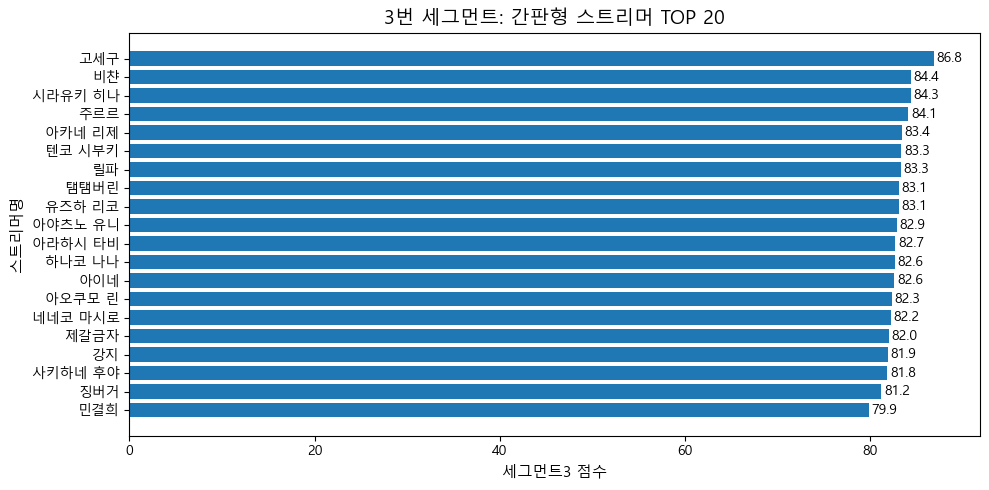

In [623]:
top20 = seg3_result.head(20).copy()

plt.figure(figsize=(10, 5))

plt.barh(top20["스트리머명"], top20["세그먼트3_score"])

for i, v in enumerate(top20["세그먼트3_score"]):
    plt.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=10)

plt.xlabel("세그먼트3 점수", fontsize=11)
plt.ylabel("스트리머명", fontsize=11)
plt.title("3번 세그먼트: 간판형 스트리머 TOP 20", fontsize=14)

plt.xlim(0, top20["세그먼트3_score"].max() + 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 그래프2. 소속구분별 TOP 10

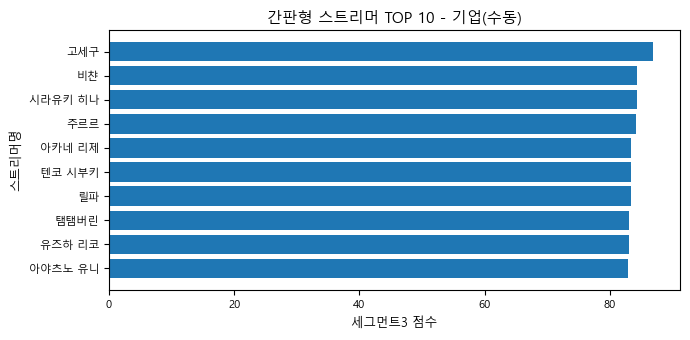

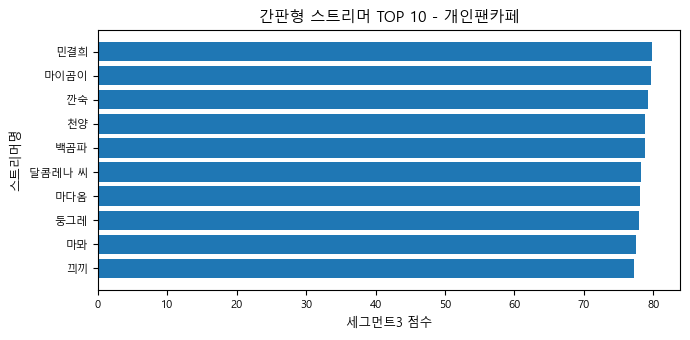

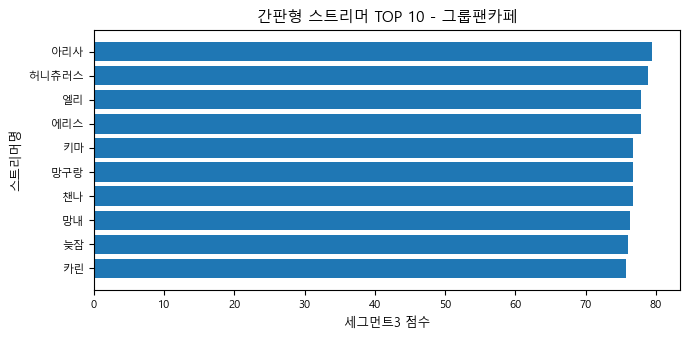

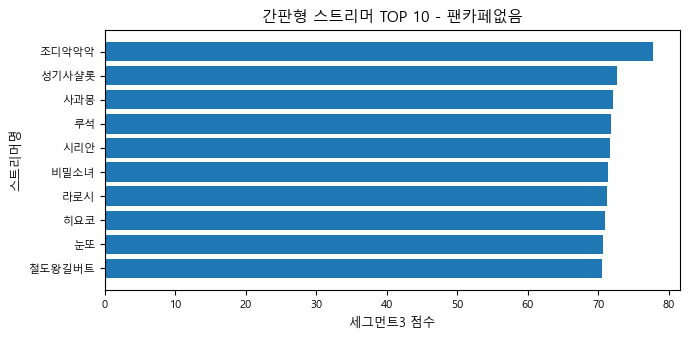

In [624]:
for group_name in seg3_result["소속구분"].unique():
    temp = seg3_result[seg3_result["소속구분"] == group_name].head(10)
    
    if len(temp) == 0:
        continue
    
    plt.figure(figsize=(7, 3.5))
    plt.barh(temp["스트리머명"], temp["세그먼트3_score"])
    plt.gca().invert_yaxis()
    
    plt.xlabel("세그먼트3 점수", fontsize=9)
    plt.ylabel("스트리머명", fontsize=9)
    plt.title(f"간판형 스트리머 TOP 10 - {group_name}", fontsize=11)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

# 그래프3. 소속구분별 평균 점수 비교

In [625]:
group_mean = (
    seg3_result
    .groupby("소속구분")[
        ["대중성_score", "방송화력_score", "팬덤체급_score", "세그먼트3_score"]
    ]
    .mean()
    .sort_values("세그먼트3_score", ascending=False)
)

group_mean

,대중성_score,방송화력_score,팬덤체급_score,세그먼트3_score
소속구분,,,,
기업(수동),66.528612,78.787298,59.919492,71.053653
그룹팬카페,46.970524,62.101863,44.874032,53.465153
개인팬카페,40.406587,54.251352,39.168223,46.450977
팬카페없음,30.795981,42.115493,26.939651,35.311312


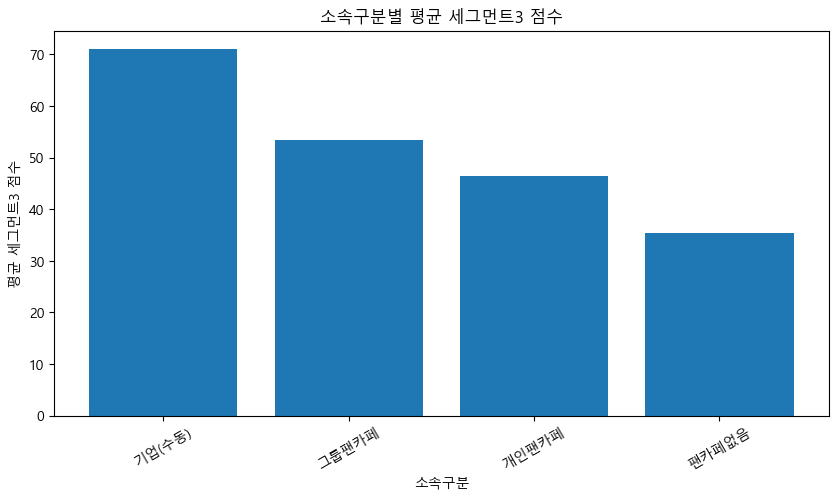

In [626]:
plt.figure(figsize=(10, 5))
plt.bar(group_mean.index, group_mean["세그먼트3_score"])
plt.xlabel("소속구분")
plt.ylabel("평균 세그먼트3 점수")
plt.title("소속구분별 평균 세그먼트3 점수")
plt.xticks(rotation=30)
plt.show()

# 그래프4. 대중성 VS 방송화력 산점도(TOP 300)

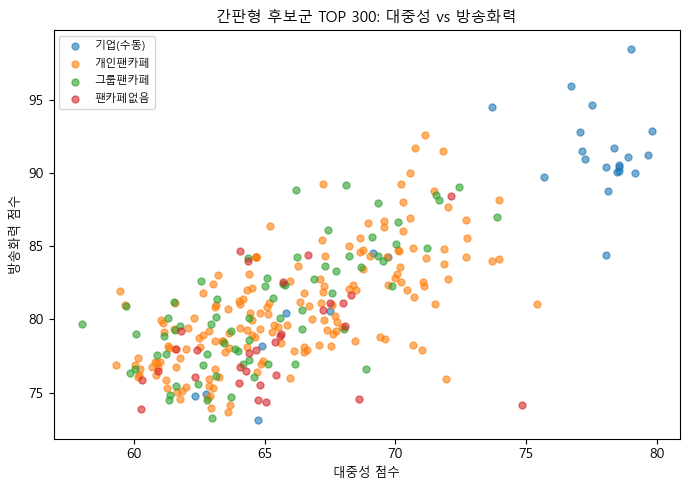

In [627]:
seg3_result = seg3_result.sort_values("세그먼트3_score", ascending=False).reset_index(drop=True)
plot_df = seg3_result.head(300).copy()

plt.figure(figsize=(7, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.6,
        s=25,
        label=group_name
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군 TOP 300: 대중성 vs 방송화력", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

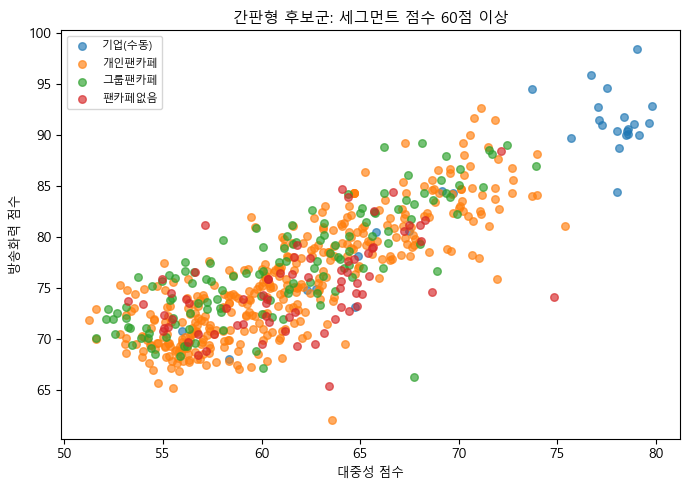

In [628]:
#세그먼트 점수가 60점 이상
plot_df = seg3_result[seg3_result["세그먼트3_score"] >= 60].copy()

plt.figure(figsize=(7, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.65,
        s=30,
        label=group_name
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군: 세그먼트 점수 60점 이상", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

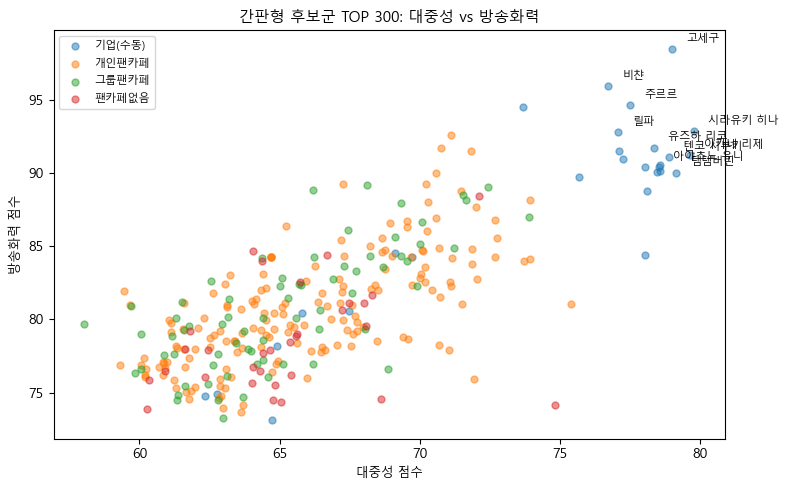

In [629]:
# 상위 10명 이름까지 표시
plot_df = seg3_result.head(300).copy()
label_df = seg3_result.head(10).copy()

plt.figure(figsize=(8, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.5,
        s=25,
        label=group_name
    )

for _, row in label_df.iterrows():
    plt.text(
        row["대중성_score"] + 0.5,
        row["방송화력_score"] + 0.5,
        row["스트리머명"],
        fontsize=8
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군 TOP 300: 대중성 vs 방송화력", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# 그래프5. 세그먼트 점수 구성 비교 TOP 15

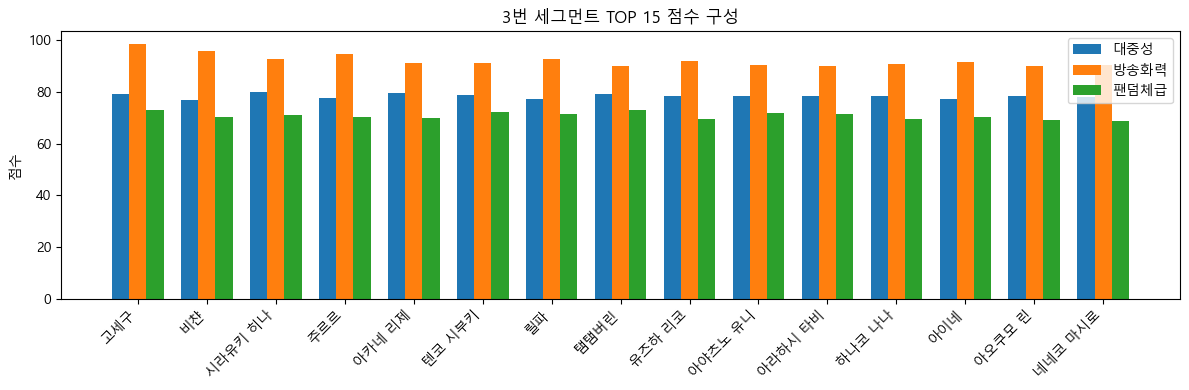

In [630]:
top15 = seg3_result.head(15).copy()

x = np.arange(len(top15))
width = 0.25

plt.figure(figsize=(12, 4))

plt.bar(x - width, top15["대중성_score"], width, label="대중성")
plt.bar(x, top15["방송화력_score"], width, label="방송화력")
plt.bar(x + width, top15["팬덤체급_score"], width, label="팬덤체급")

plt.xticks(x, top15["스트리머명"], rotation=45, ha="right")
plt.ylabel("점수")
plt.title("3번 세그먼트 TOP 15 점수 구성")
plt.legend()
plt.tight_layout()
plt.show()